# Agentic AI - Chart Generation

## Introduction

In this lab, you will implement an agentic workflow that generates data visualizations. 

A multi-modal LLM will review the first draft chart, identify potential improvements—such as chart type, labels, or color choices—and then rewrite the chart generation code to produce a more effective visualization.

The steps that the workflow will carry out are:

1. **Generate an initial version (V1):**
Use a Large Language Model (LLM) to create the first version of the plotting code.

2. **Execute code and create chart:** 
Run the generated code and display the resulting chart. ** (check everywhere)

3. **Reflect on the output:**
Evaluate both the code and the chart using an LLM to detect areas for improvement (e.g., clarity, accuracy, design).

4. **Generate and execute improved version (V2):**
Produce a refined version of the plotting code based on reflection insights and render the enhanced chart.

<br>

<img src='./chart_gen_workflow.png'>


## Imports

In [1]:
# === Standard Library ===
import os
import re
import json
import base64
import mimetypes
from pathlib import Path

# === Third-Party ===
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image  # (kept if you need it elsewhere)
from dotenv import load_dotenv
from openai import OpenAI
from html import escape

# Local helper module
import utils

## Helper Function

In [2]:
# === Data Loading ===
def load_and_prepare_data(csv_path: str) -> pd.DataFrame:
    """Load CSV and derive date parts commonly used in charts."""
    df = pd.read_csv(csv_path)
    # Be tolerant if 'date' exists
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df["quarter"] = df["date"].dt.quarter
        df["month"] = df["date"].dt.month
        df["year"] = df["date"].dt.year
    return df

In [3]:
def get_response(model: str, prompt: str) -> str:
    
    response = openai_client.responses.create(
            model=model,
            input=prompt,
    )
    
    return response.output_text

In [4]:
def image_openai_call(model_name: str, prompt: str, media_type: str, b64: str) -> str:
    data_url = f"data:{media_type};base64,{b64}"
    resp = openai_client.responses.create(
        model=model_name,
        input=[
            {
                "role": "user",
                "content": [
                    {"type": "input_text", "text": prompt},
                    {"type": "input_image", "image_url": data_url},
                ],
            }
        ],
    )
    content = (resp.output_text or "").strip()
    return content

In [5]:
def encode_image_b64(path: str) -> tuple[str, str]:
    """Return (media_type, base64_str) for an image file path."""
    mime, _ = mimetypes.guess_type(path) #image/png or image/jpeg
    media_type = mime or "image/png"
    with open(path, "rb") as f:  #open the image in binary mode
        b64 = base64.b64encode(f.read()).decode("utf-8") #convert image to base64 string
    return media_type, b64

In [6]:
# Takes some text (usually code) and ensures it is wrapped inside <execute_python> </execute_python> tags
def ensure_execute_python_tags(text: str) -> str:
    """Normalize code to be wrapped in <execute_python>...</execute_python>."""
    text = text.strip()
    # Strip ```python fences if present
    text = re.sub(r"^```(?:python)?\s*|\s*```$", "", text).strip() #Remove Markdown code fences ```python and ``` if they exist
    if "<execute_python>" not in text:
        text = f"<execute_python>\n{text}\n</execute_python>"
    return text

## Initialize Environment & Client

API keys stored in a `.env` file:
```bash
OPENAI_API_KEY=your-open-api-key
```

In [7]:
# === Env & Clients ===
load_dotenv()
openai_api_key = os.getenv("OPENAI_API_KEY")

# the client read keys from env by default; explicit is also fine:
openai_client = OpenAI(api_key=openai_api_key) if openai_api_key else OpenAI()


## Loading the Dataset

In [8]:
# Use this utils.py function to load the data into a dataframe
df = load_and_prepare_data('coffee_sales.csv')

# Grab a random sample to display
utils.print_html(df.sample(n=5), title="Random Sample of Coffee Sales Data")

date,time,cash_type,card,price,coffee_name,quarter,month,year
2024-05-23,07:36,card,ANON-0000-0000-0180,3.772,Cappuccino,2,5,2024
2024-10-04,16:33,card,ANON-0000-0000-0713,3.576,Latte,4,10,2024
2024-11-25,13:25,card,ANON-0000-0000-0944,3.086,Americano with Milk,4,11,2024
2025-02-18,14:20,card,ANON-0000-0000-1225,3.576,Cocoa,1,2,2025
2024-11-14,08:32,card,ANON-0000-0000-0898,2.106,Espresso,4,11,2024


## Building the Code Generation Pipeline

### Step 1 — Generate Code to Create a Chart (V1)

The question you’ll ask the model is:  
**“Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.”**

The LLM’s output will be Python code using the **matplotlib** library. Instead of displaying the chart directly, the code will be written between `<execute_python>` tags so it can be extracted and run in later steps.

In [9]:
def generate_chart_code(instruction: str, model: str, out_path_v1: str) -> str:
    """Generate Python code to make a plot with matplotlib using tag-based wrapping."""

    prompt = f"""
    You are a data visualization expert.

    Return your answer *strictly* in this format:

    <execute_python>
    # valid python code here
    </execute_python>

    Do not add explanations, only the tags and the code.

    The code should create a visualization from a DataFrame 'df' with these columns:
    - date (M/D/YY)
    - time (HH:MM)
    - cash_type (card or cash)
    - card (string)
    - price (number)
    - coffee_name (string)
    - quarter (1-4)
    - month (1-12)
    - year (YYYY)

    User instruction: {instruction}

    Requirements for the code:
    1. Assume the DataFrame is already loaded as 'df'.
    2. Use matplotlib for plotting.
    3. Add clear title, axis labels, and legend if needed.
    4. Save the figure as '{out_path_v1}' with dpi=300.
    5. Do not call plt.show().
    6. Close all plots with plt.close().
    7. Add all necessary import python statements

    Return ONLY the code wrapped in <execute_python> tags.
    """

    response = get_response(model, prompt)
    return response

In [10]:
# Generate initial code
code_v1 = generate_chart_code(
    instruction="Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.", 
    model="gpt-4o-mini", 
    out_path_v1="chart_v1.png"
)

utils.print_html(code_v1, title="LLM output with first draft code")

### Step 2 — Execute Code and Create Chart (V1)

> **LLM cannot run code, but it can generate code and request that you run it.**

In this step, you’ll use a regular expression to extract the Python code that the LLM generated in the previous step (the part written between `<execute_python>` tags). Once extracted, you’ll run this code to produce the **first draft chart**.  

Here's how it works:

1. **Extract the code:**  
   A regex pattern is used to grab the code that’s wrapped inside the `<execute_python>` tags.

2. **Execute the code:**
   The extracted code is run in a predefined global context where the DataFrame `df` is already available. This means your code can directly use df without needing to reload the dataset.

3. **Generate the chart::**
   If the code executes successfully, it will create a chart and save it as `chart_v1.png`.

4. **View the chart in the notebook:**
   The saved chart is then displayed inline using `utils.print_html`, making it easy for you to review the results.

By completing this step, you’ll have your first draft visualization (V1).


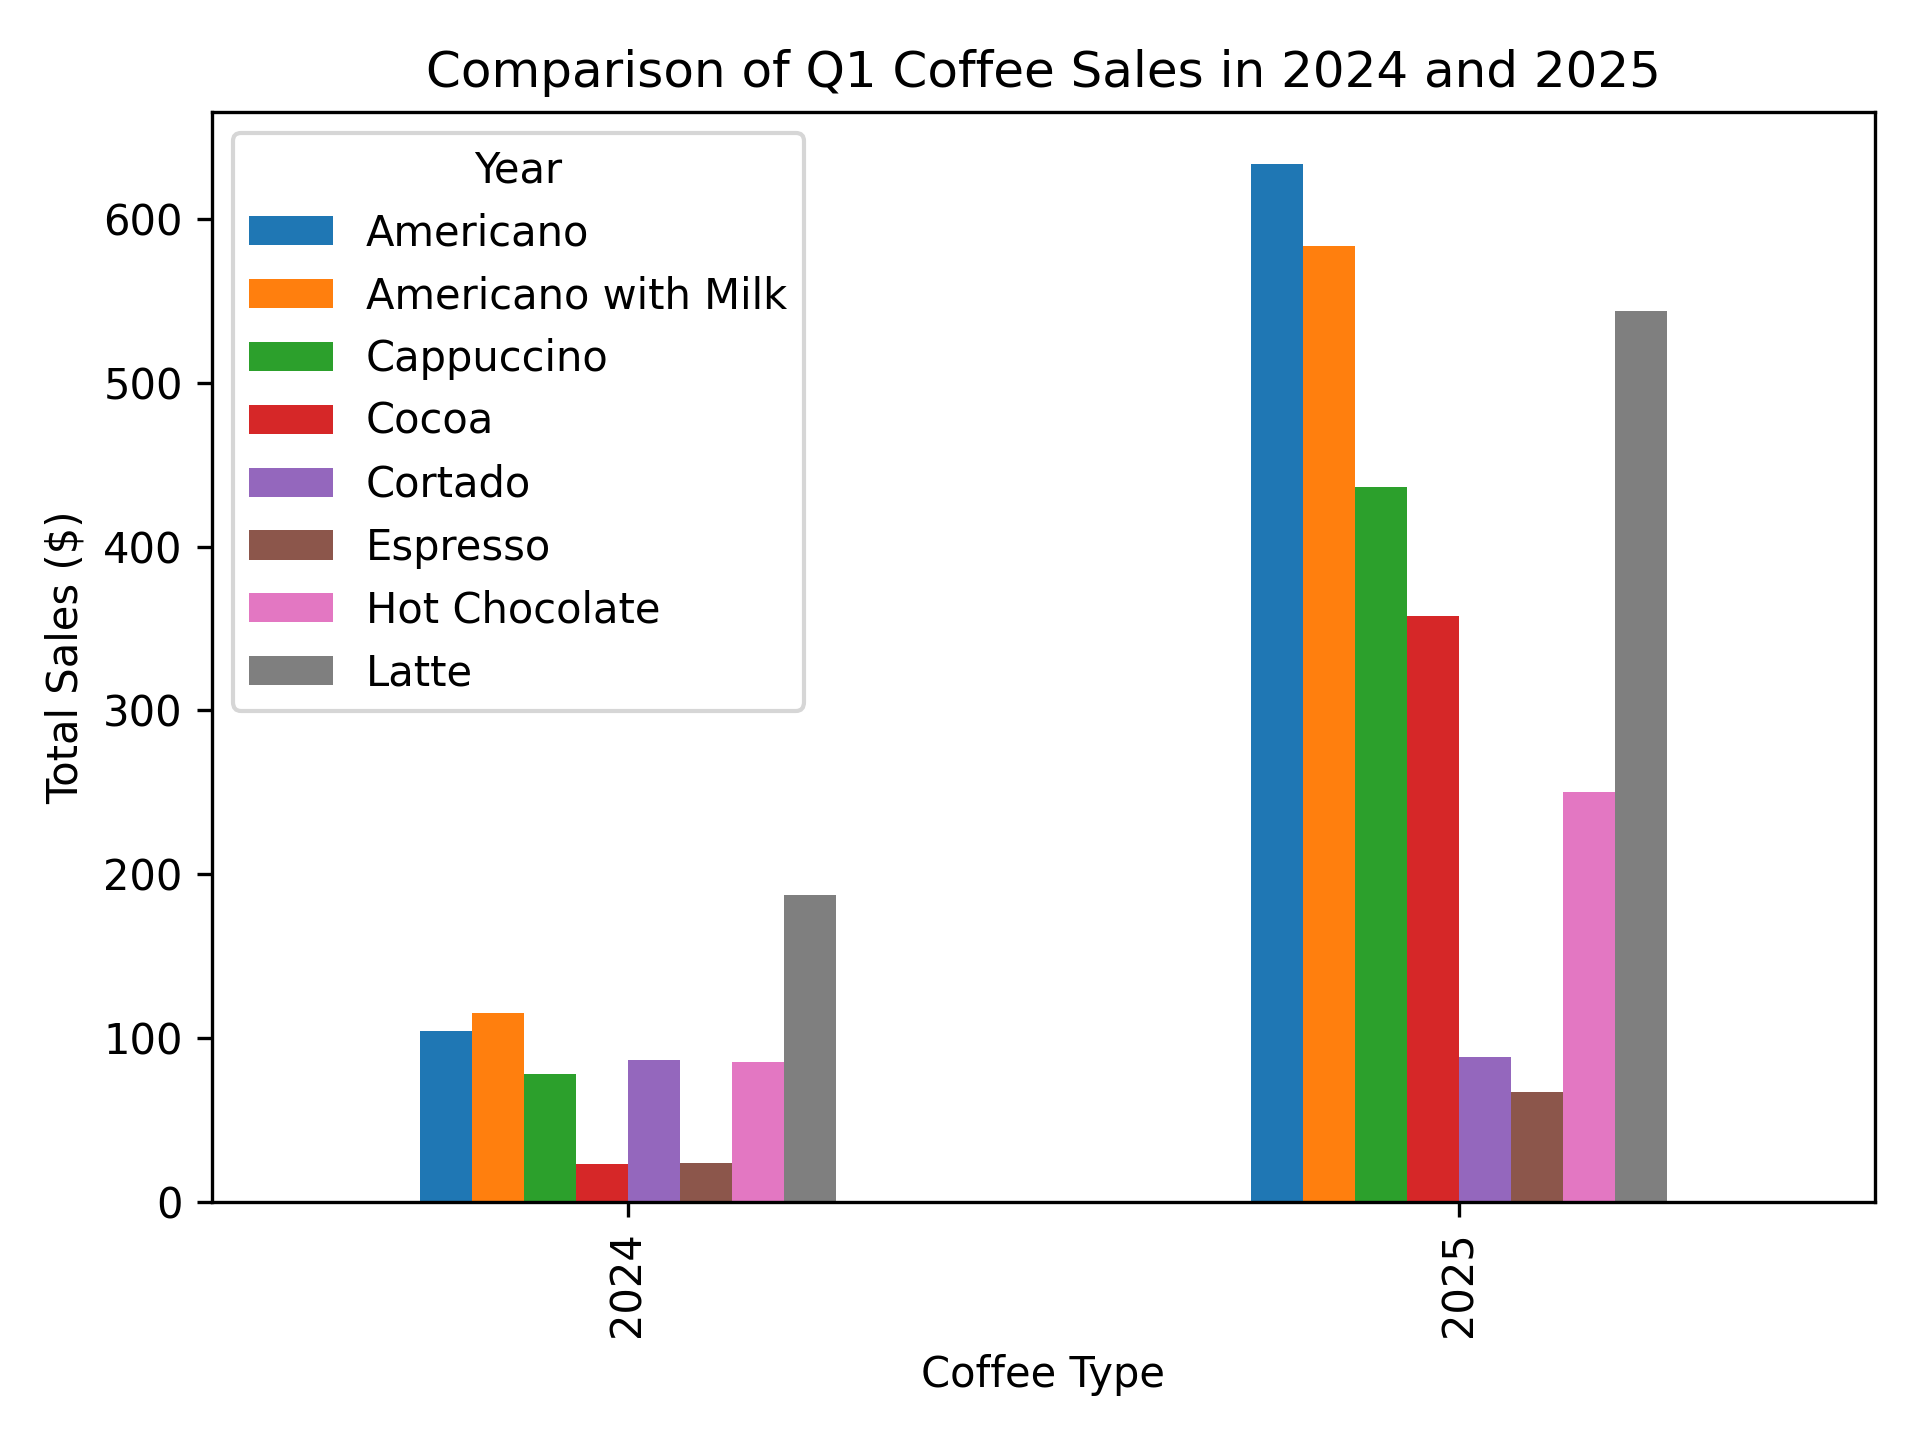

<Figure size 1000x600 with 0 Axes>

In [11]:
# Get the code within the <execute_python> tags
match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v1)
if match:
    initial_code = match.group(1).strip()
    utils.print_html(initial_code, title="Extracted Code to Execute")
    exec_globals = {"df": df}
    exec(initial_code, exec_globals)

# If code run successfully, the file chart_v1.png should have been generated
utils.print_html(
    content="chart_v1.png",
    title="Generated Chart (V1)",
    is_image=True
)

### Step 3 — Reflect on the output V1 and Generate Improved Code (V2)

The goal here is to simulate how a human would review a first draft of a chart—looking for strengths, weaknesses, and areas for improvement.

Here’s what happens:

**1. Provide the chart to the LLM:**
The generated chart (chart_v1.png) is shared with the LLM so it can “see” the visualization.

**2. Analyze the chart visually:**
The LLM reviews elements like clarity, labeling, accuracy, and overall readability.

**3. Generate feedback:**
The LLM suggests improvements—for example, fixing axis labels, adjusting the chart type, improving color choices, or highlighting missing legends.

**4. Generate refined code:**
Based on the feedback, the LLM produces a new version of the plotting code (V2).

In [16]:
def reflect_on_image_and_regenerate(
    chart_path: str,
    instruction: str,
    model_name: str,
    out_path_v2: str,
    code_v1: str,  
) -> tuple[str, str]:
    """
    Critique the chart IMAGE and the original code against the instruction, 
    then return refined matplotlib code.
    Returns (feedback, refined_code_with_tags).
    """
    
    media_type, b64 = encode_image_b64(chart_path)     #A way to convert binary data (like images) into text (string).
    

    prompt = f"""
    You are a data visualization expert.
    Your task: critique the attached chart and the original code against the given instruction,
    then return improved matplotlib code.

    Original code (for context):
    {code_v1}

    OUTPUT FORMAT (STRICT):
    1) First line: a valid JSON object with ONLY the "feedback" field.
    Example: {{"feedback": "The legend is unclear and the axis labels overlap."}}

    2) After a newline, output ONLY the refined Python code wrapped in:
    <execute_python>
    ...
    </execute_python>

    3) Import all necessary libraries in the code. Don't assume any imports from the original code.

    HARD CONSTRAINTS:
    - Do NOT include Markdown, backticks, or any extra prose outside the two parts above.
    - Use pandas/matplotlib only (no seaborn).
    - Assume df already exists; do not read from files.
    - Save to '{out_path_v2}' with dpi=300.
    - Always call plt.close() at the end (no plt.show()).
    - Include all necessary import statements.

    Schema (columns available in df):
    - date (M/D/YY)
    - time (HH:MM)
    - cash_type (card or cash)
    - card (string)
    - price (number)
    - coffee_name (string)
    - quarter (1-4)
    - month (1-12)
    - year (YYYY)

    Instruction:
    {instruction}
    """


    # In case the name is "Claude" or "Anthropic", use the safe helper
    content = image_openai_call(model_name, prompt, media_type, b64)

    # --- Parse ONLY the first JSON line (feedback) ---
    lines = content.strip().splitlines()
    json_line = lines[0].strip() if lines else ""

    try:
        obj = json.loads(json_line) # Convert a JSON-formatted string into a Python object.
    except Exception as e:
        # Fallback: try to capture the first {...} in all the content
        m_json = re.search(r"\{.*?\}", content, flags=re.DOTALL)
        if m_json:
            try:
                obj = json.loads(m_json.group(0))
            except Exception as e2:
                obj = {"feedback": f"Failed to parse JSON: {e2}"}
        else:
            obj = {"feedback": f"Failed to find JSON: {e}"}

    # --- Extract refined code from <execute_python>...</execute_python> ---
    m_code = re.search(r"<execute_python>([\s\S]*?)</execute_python>", content)
    refined_code_body = m_code.group(1).strip() if m_code else ""
    refined_code = ensure_execute_python_tags(refined_code_body)

    feedback = str(obj.get("feedback", "")).strip()
    return feedback, refined_code



In [17]:
# Generate feedback alongside reflected code
feedback, code_v2 = reflect_on_image_and_regenerate(
    chart_path="chart_v1.png",            
    instruction="Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.", 
    model_name="o4-mini",
    out_path_v2="chart_v2.png",
    code_v1=code_v1,   # pass in the original code for context        
)

utils.print_html(feedback, title="Feedback on V1 Chart")
utils.print_html(code_v2, title="Regenerated Code Output (V2)")

### Step 4: Execute the improved code (V2) and create the enhanced chart

Now you’ll execute the refined code returned by the reflection step.  The code inside the `<execute_python>` tags is extracted, run against the dataset, and used to generate the updated chart.  

If the execution is successful, you’ll see the new image (`chart_v2.png`) displayed below as the **Regenerated Chart (V2)**.  


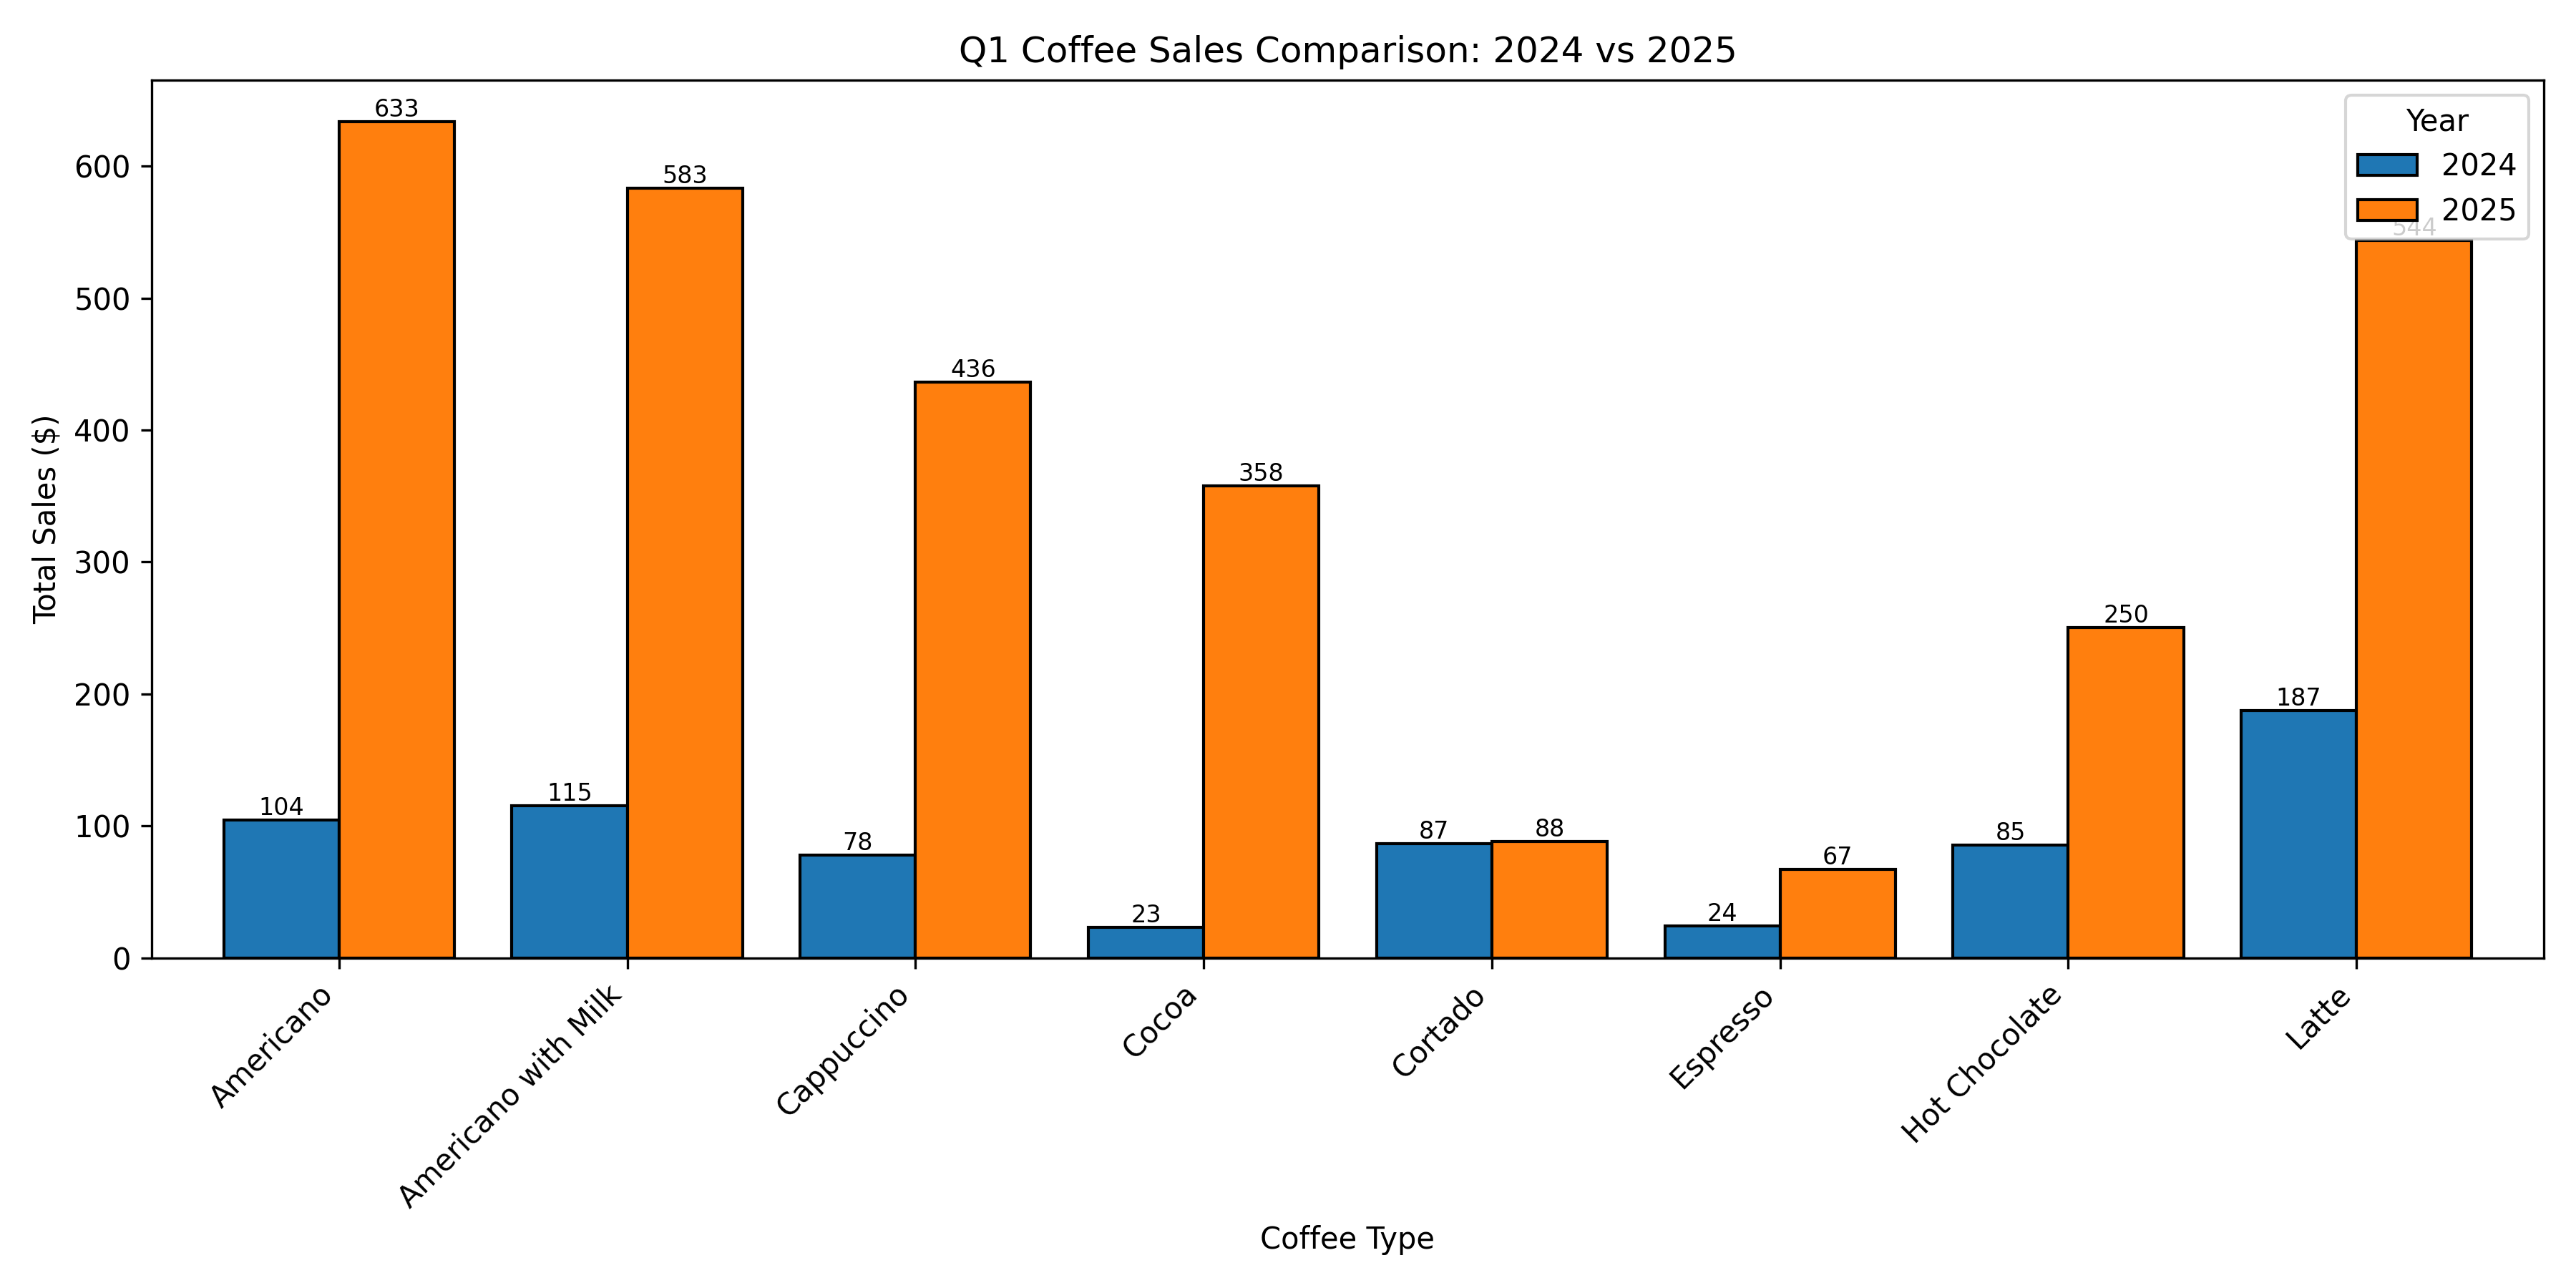

In [18]:
# Get the code within the <execute_python> tags
match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v2)
if match:
    reflected_code = match.group(1).strip()
    exec_globals = {"df": df}
    exec(reflected_code, exec_globals)

# If code run successfully, the file chart_v2.png should have been generated
utils.print_html(
    content="chart_v2.png",
    title="Regenerated Chart (V2)",
    is_image=True
)

## Put it all together — creating the end-to-end workflow

Now it’s time to wrap everything into a single automated workflow the agent can run from start to finish.

The `run_workflow` function links together the components you implemented earlier:

1) **Load and prepare data** — via `utils.load_and_prepare_data(...)`.  
2) **Generate V1 code** — with `generate_chart_code(...)`, which returns the first-draft matplotlib code (wrapped in `<execute_python>` tags).  
3) **Execute V1 immediately** — the workflow extracts the code between `<execute_python>` tags and runs it to produce the first chart image.  
4) **Reflect and refine** — `reflect_on_image_and_regenerate(...)` critiques the V1 image (and the original code) against the instruction, returns concise **feedback** plus **revised code (V2)**.  
5) **Execute V2 immediately** — the refined code is extracted and executed to generate the improved chart.

### What this workflow accepts
- **`dataset_path`**: location of the input CSV.  
- **`user_instructions`**: the chart request (e.g., “Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.”).  
- **`generation_model`**: model used for the initial code generation.  
- **`reflection_model`**: model used for the image-based reflection and code refinement.  
- **`image_basename`**: base filename for saving chart images (e.g., `chart_v1.png`, `chart_v2.png`). 

In [20]:
def run_workflow(
    dataset_path: str,
    user_instructions: str,
    generation_model: str,
    reflection_model: str,   
    image_basename: str = "chart",
):
    """
    End-to-end pipeline:
      1) load dataset
      2) generate V1 code
      3) execute V1 → produce chart_v1.png
      4) reflect on V1 (image + original code) → feedback + refined code
      5) execute V2 → produce chart_v2.png

    Returns a dict with all artifacts (codes, feedback, image paths).
    """
    # 0) Load dataset; utils handles parsing and feature derivations (e.g., year/quarter)
    df = load_and_prepare_data(dataset_path)
    utils.print_html(df.sample(n=5), title="Random Sample of Dataset")

    # Paths to store charts
    out_v1 = f"{image_basename}_v1.png"
    out_v2 = f"{image_basename}_v2.png"

    # 1) Generate code (V1)
    utils.print_html("Step 1: Generating chart code (V1)… 📈")
    code_v1 = generate_chart_code(
        instruction=user_instructions,
        model=generation_model,
        out_path_v1=out_v1,
    )
    utils.print_html(code_v1, title="LLM output with first draft code (V1)")

    # 2) Execute V1 (hard-coded: extract <execute_python> block and run immediately)
    utils.print_html("Step 2: Executing chart code (V1)… 💻")
    match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v1)
    if match:
        initial_code = match.group(1).strip()
        exec_globals = {"df": df}
        exec(initial_code, exec_globals)
    utils.print_html(out_v1, is_image=True, title="Generated Chart (V1)")

    # 3) Reflect on V1 (image + original code) to get feedback and refined code (V2)
    utils.print_html("Step 3: Reflecting on V1 (image + code) and generating improvements… 🔁")
    feedback, code_v2 = reflect_on_image_and_regenerate(
        chart_path=out_v1,
        instruction=user_instructions,
        model_name=reflection_model,
        out_path_v2=out_v2,
        code_v1=code_v1,  # pass original code for context
    )
    utils.print_html(feedback, title="Reflection feedback on V1")
    utils.print_html(code_v2, title="LLM output with revised code (V2)")

    # 4) Execute V2 (hard-coded: extract <execute_python> block and run immediately)
    utils.print_html("Step 4: Executing refined chart code (V2)… 🖼️")
    match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v2)
    if match:
        reflected_code = match.group(1).strip()
        exec_globals = {"df": df}
        exec(reflected_code, exec_globals)
    utils.print_html(out_v2, is_image=True, title="Regenerated Chart (V2)")

    return {
        "code_v1": code_v1,
        "chart_v1": out_v1,
        "feedback": feedback,
        "code_v2": code_v2,
        "chart_v2": out_v2,
    }


date,time,cash_type,card,price,coffee_name,quarter,month,year
2025-03-20,15:06,card,ANON-0000-0000-1158,3.576,Cappuccino,1,3,2025
2024-07-18,10:24,card,ANON-0000-0000-0382,3.282,Cappuccino,3,7,2024
2025-03-06,09:24,card,ANON-0000-0000-1207,3.086,Americano with Milk,1,3,2025
2025-01-12,16:09,card,ANON-0000-0000-1097,3.086,Americano with Milk,1,1,2025
2024-03-25,10:35,card,ANON-0000-0000-0078,3.870,Latte,1,3,2024



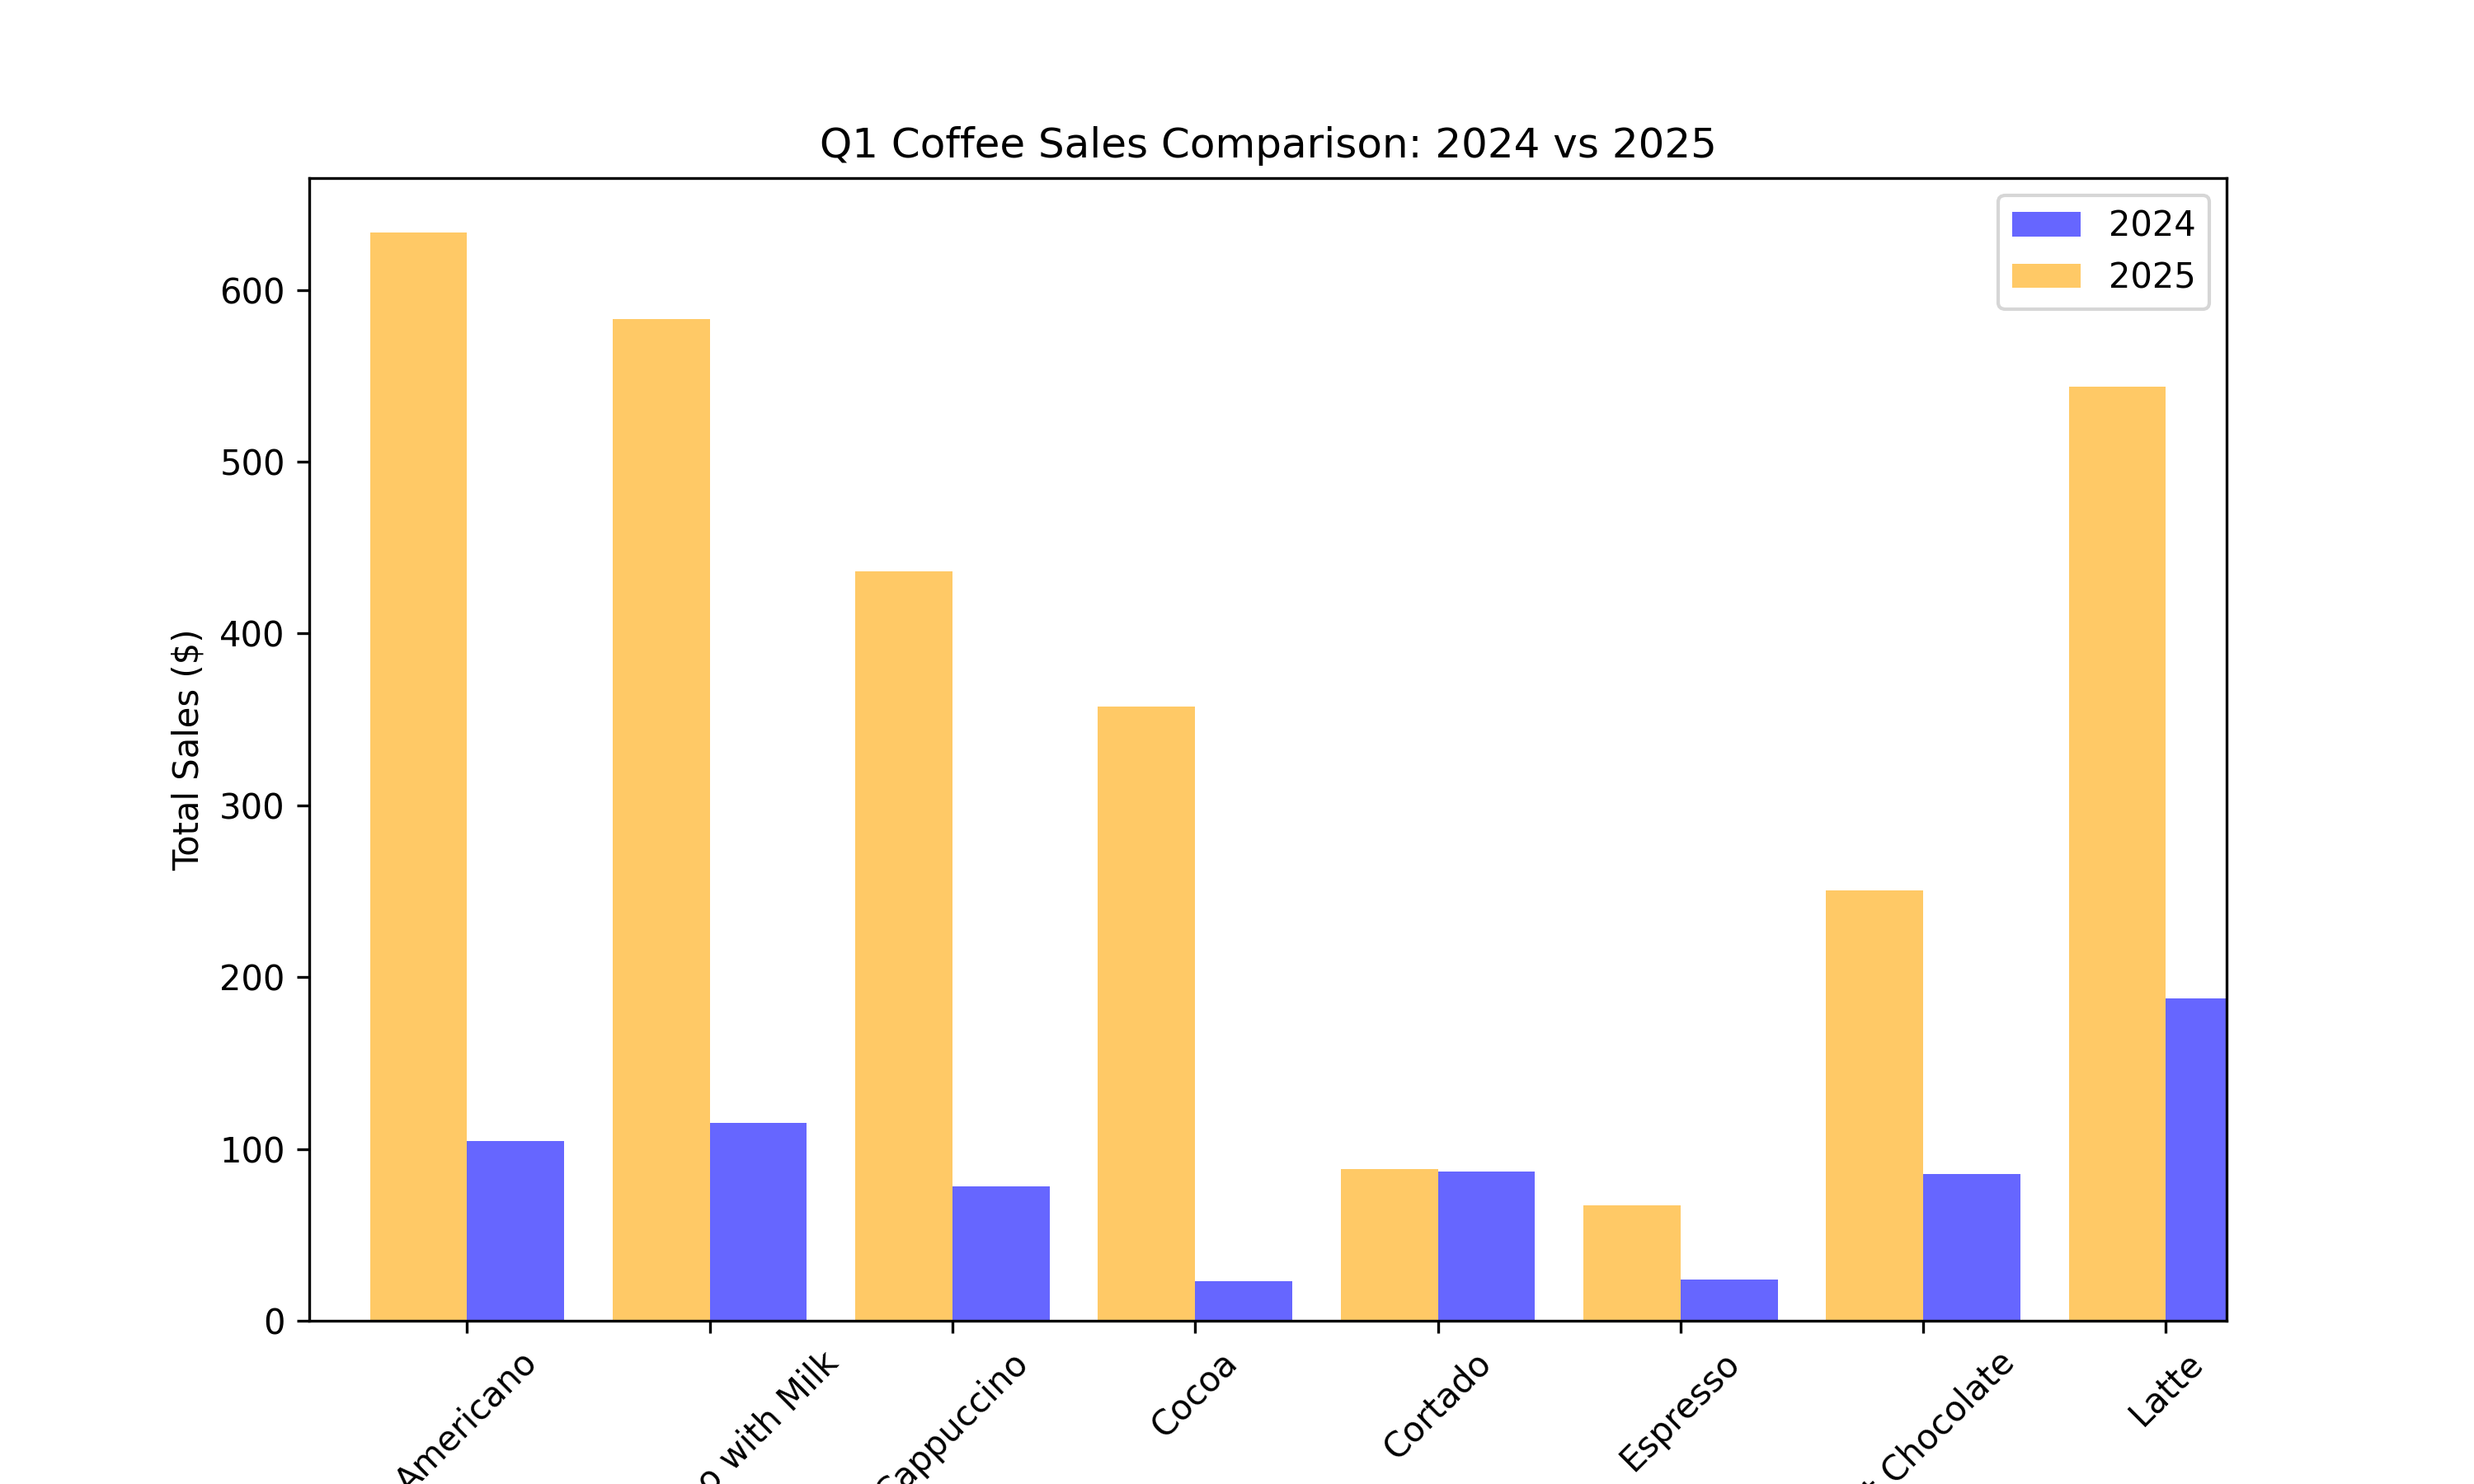


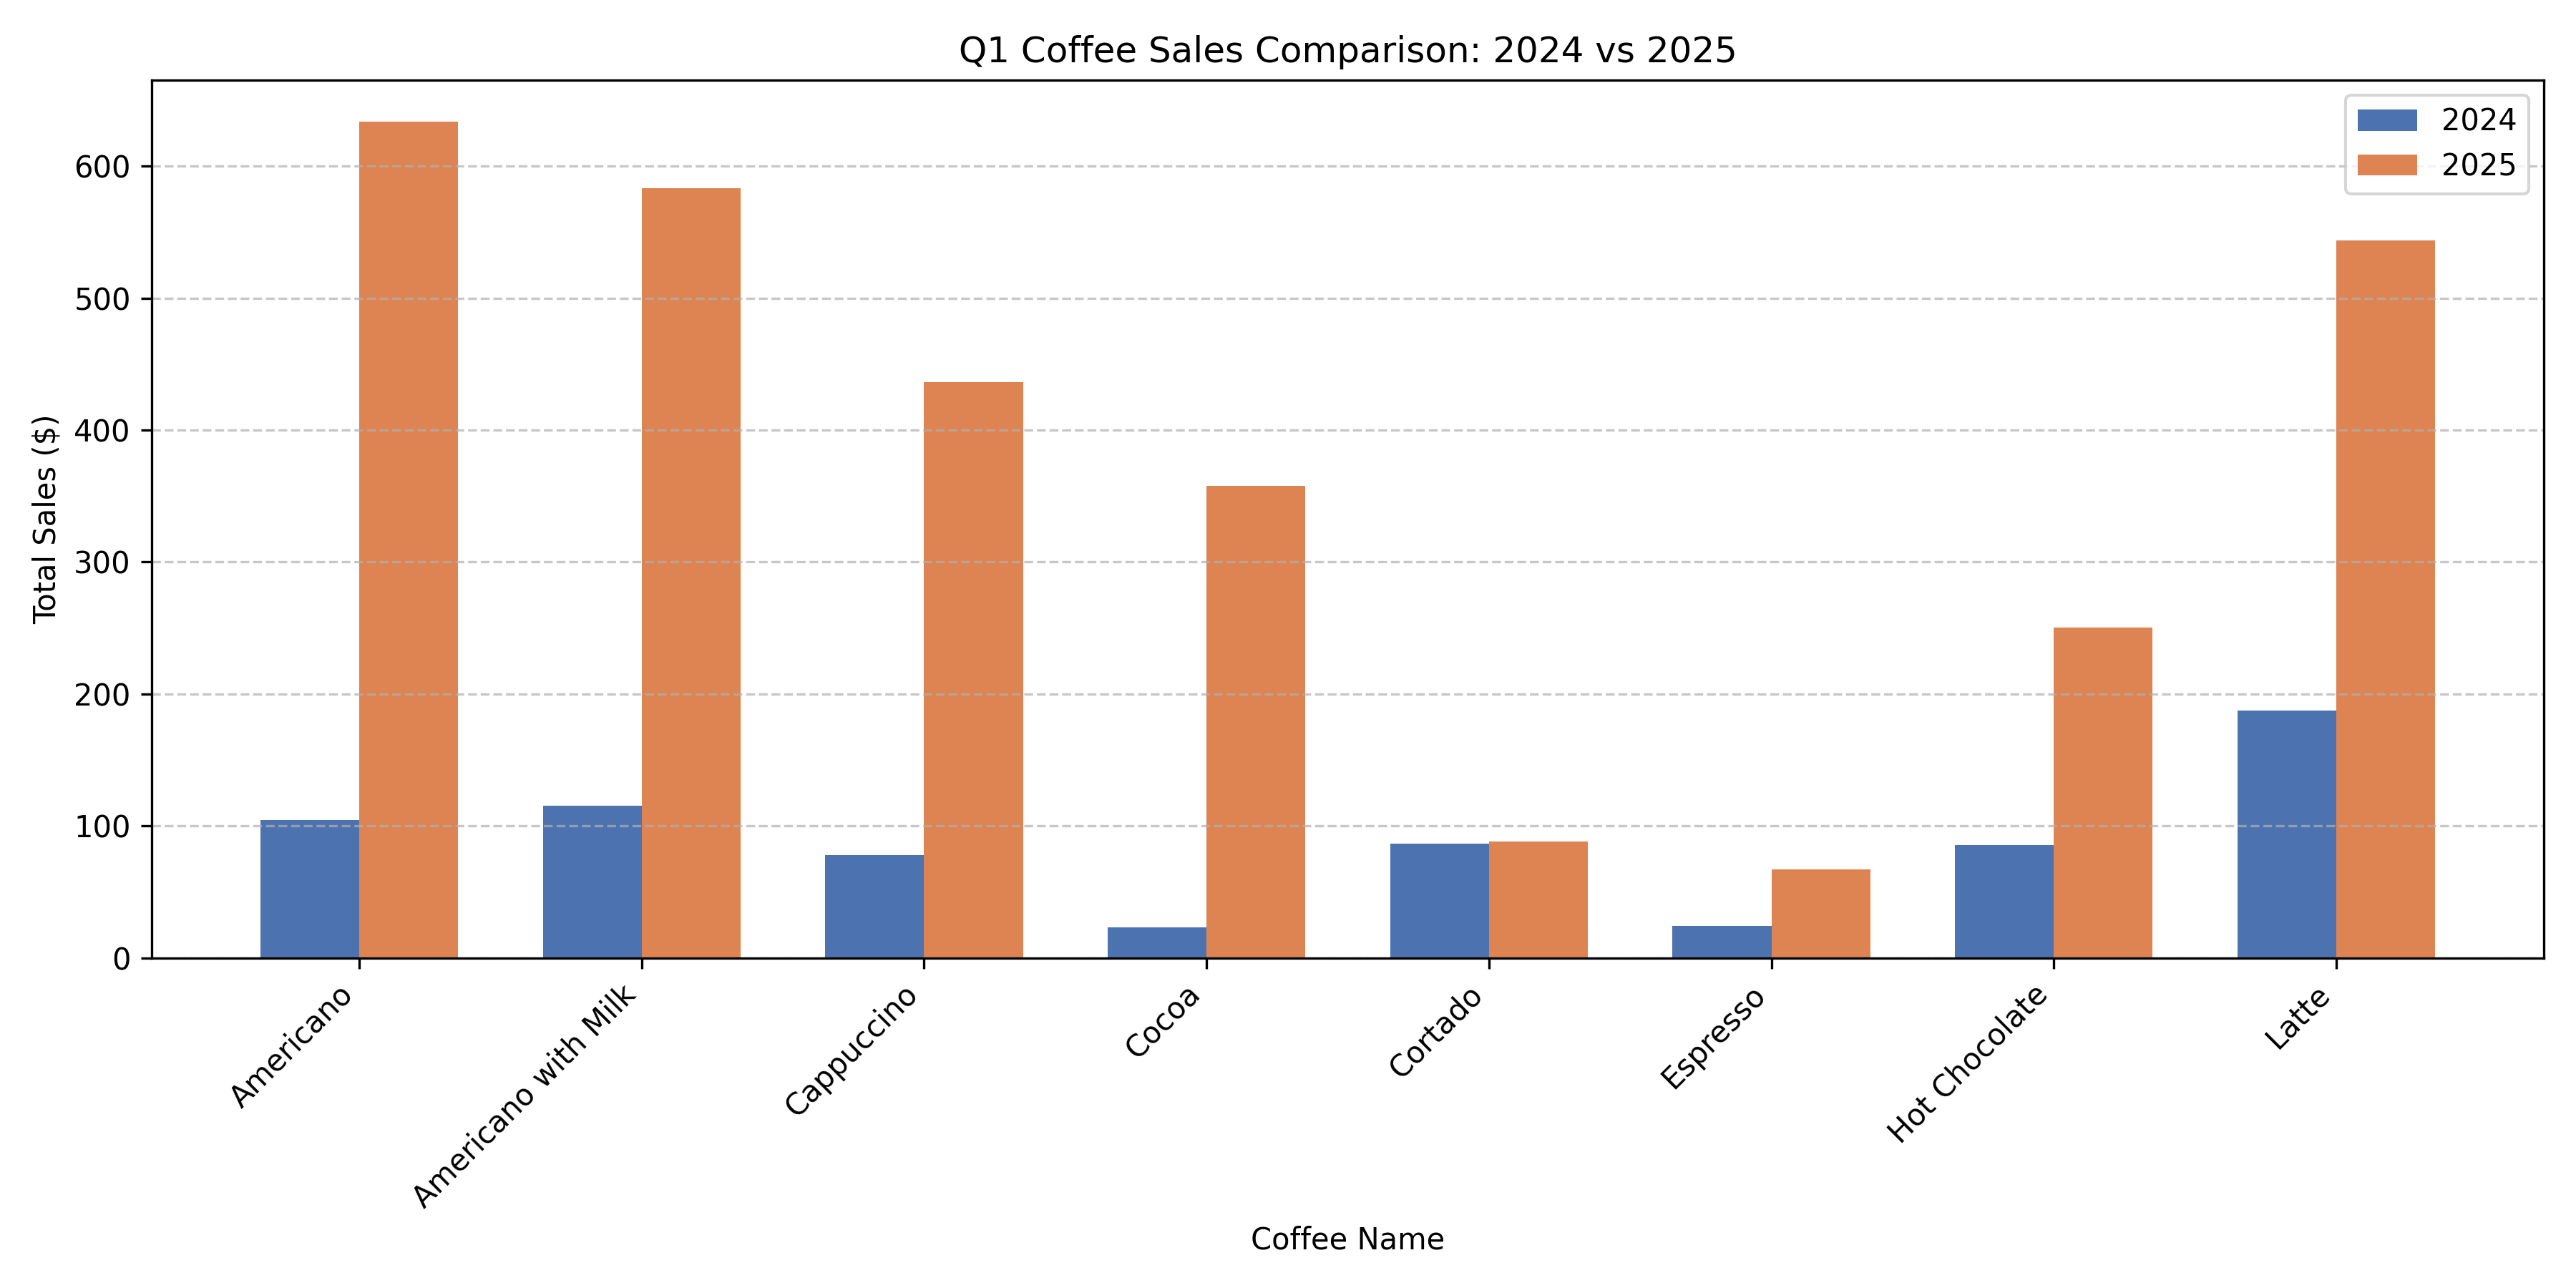

In [21]:
# Here, insert your updates
user_instructions="Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv." # write your instruction here
generation_model="gpt-4o-mini"
reflection_model="o4-mini"
image_basename="drink_sales"

# Run the complete agentic workflow
_ = run_workflow(
    dataset_path="coffee_sales.csv",
    user_instructions=user_instructions,
    generation_model=generation_model,
    reflection_model=reflection_model,
    image_basename=image_basename
)

## Customize and Experiment

After trying the example above, feel free to update the `user_instructions` parameter with your own chart prompts.  
Remember to also adjust the `image_basename` so each run saves its results under a new filename — this keeps your charts organized and avoids overwriting previous outputs.

### Choosing models

You can mix and match different models for generation and reflection. For example:
- Use a fast model for initial code generation (`gpt-4.1-mini` or `gpt-3.5-turbo`).  
- Use a stronger reasoning model for reflection (`gpt-4.1`).  

This flexibility lets you explore trade-offs between speed and quality.

**Important:** Because Large Language Models (LLMs) are stochastic, every run may return slightly different results.
You are encouraged to experiment with different models and combinations to find the setup that works best for **you**.


In [1]:
#your code here